> This assignment should be done in Jupyter Notebook

---


## **1. Option Implied Volatility:** Given market price of an option, solve for the volatility to match the Black-Scholes option price to the market price.

In this exercise, you will implement a **root searching algorithm using Newton-Raphson method**. Feel free to use AI to help you understand the math, but you must write the program on your own. You will then use this algorithm to find the implied volatility for the following options.

On Friday 10/31/2025, Palantir Technologies Inc (PLTR) closed at $200.47.

* Its 1/16/2026 200-strike call option last trading price was \$23.50
* Its 1/16/2026 200-strike put option last trading price was $21.00.
* The risk free rate is 3.91%
* PLTR does not pay dividends

**Assuming these options are European**, calculate the implied volatility of the above put and call option using Newton-Raphson.

Are the implied volatility for call and put identical? Explain why or why not.

In [2]:
from datetime import date
import numpy as np
from numpy import random
from scipy.stats import norm
import math
import matplotlib.pyplot as plt

In [3]:
# Given parameters
S_0 = 200.47
K = 200
rf = 0.0391

T = (date(2026,1,16) - date(2025, 10, 31)).days/365
print(T)

C_mkt = 23.5
P_mkt = 21

0.21095890410958903


In [4]:
# Finding the CALL PRICE
# Set initial Guess of Sigma_0
sigma_0 = (C_mkt*np.sqrt(2*np.pi))/(S_0*np.sqrt(T))

sigma_new_call = sigma_0
diff_between_C_BS_and_C_mkt = 0.5 # Just an arbitrary number

while diff_between_C_BS_and_C_mkt > 10**(-9):
    d_1 = (np.log(S_0/K) + (rf + (sigma_new_call**2)/2)*T)/(sigma_new_call * np.sqrt(T))
    d_2 = d_1 - sigma_new_call * np.sqrt(T)
    
    # print(f"""
    # d_1: {d_1:.5f}
    # d_2: {d_2:.5f}
    # """)
    
    # Calculate Model Price ($C_{BS}$)
    C_BS = S_0*norm.cdf(d_1) - K*np.exp(-rf*T)*norm.cdf(d_2)
    # print(f"""Call Price According to Black Scholes: {C_BS:.5f}""")
    
    # Calculate Vega ($\nu$)
    vega = S_0 * np.sqrt(T)*(1/np.sqrt(2*np.pi))*np.exp(-(d_1**2)/2)
    # print(f"Vega: {vega:.3f}")
    
    # Update the new sigma
    sigma_new_call = sigma_new_call - (C_BS-C_mkt)/vega
    # print(f"sigma_new_call: {sigma_new_call}")
    
    # Update new diff_between_C_BS_and_C_mkt
    diff_between_C_BS_and_C_mkt = abs(C_BS - C_mkt)

# To produce the final Call Price
print(f"Call Price according to Black Scholes: ${C_BS}")
print(f"Call Implied Volatility is: {sigma_new_call:.5f}")

Call Price according to Black Scholes: $23.49999999995657
Call Implied Volatility is: 0.61584


In [5]:
# Finding the PUT PRICE
# Set initial Guess of Sigma_0
sigma_0 = (P_mkt*np.sqrt(2*np.pi))/(S_0*np.sqrt(T))

sigma_new_put = sigma_0
diff_between_P_BS_and_P_mkt = 0.5 # Just an arbitrary number

while diff_between_P_BS_and_P_mkt > 10**(-9):
    d_1 = (np.log(S_0/K) + (rf + (sigma_new_put**2)/2)*T)/(sigma_new_put * np.sqrt(T))
    d_2 = d_1 - sigma_new_put * np.sqrt(T)
    
    # print(f"""
    # d_1: {d_1:.5f}
    # d_2: {d_2:.5f}
    # """)
    
    # Calculate Model Price ($P_{BS}$)
    P_BS = K*np.exp(-rf*T)*norm.cdf(-d_2) - S_0*norm.cdf(-d_1)
    # print(f"""Put Price According to Black Scholes: {P_BS:.5f}""")
    
    # Calculate Vega ($\nu$)
    vega = S_0 * np.sqrt(T)*(1/np.sqrt(2*np.pi))*np.exp(-(d_1**2)/2)
    # print(f"Vega: {vega:.3f}")
    
    # Update the new sigma
    sigma_new_put = sigma_new_put - (P_BS - P_mkt)/vega
    # print(f"sigma_new_put: {sigma_new_put}")
    
    # Update new diff_between_P_BS_and_P_mkt
    diff_between_P_BS_and_P_mkt = abs(P_BS - P_mkt)

# To produce the final Put Price
print(f"Put Price according to Black Scholes: ${P_BS}")
print(f"Put Implied Volatility is: {sigma_new_put:.5f}")

Put Price according to Black Scholes: $20.999999999868734
Put Implied Volatility is: 0.60514


The implied volatility for call (0.61584) and the implied volatility for put (0.60514) are not identitical.

This goes against the theory of [put-call parity](https://quant.stackexchange.com/questions/7604/does-implied-volatility-vary-for-calls-vs-puts) that suggest that European put and call options with the same maturity and strike price do have the same implied volatility unless there's an arbitrage opportunity. This suggest the precense which aligns with practice of stuff like the bid-ask spreads and liquidity issues which is suggested when the observed prices of European options don't align to the theory.

---

## **2.** In this part of the exercise, we'll assume the above options are **American** as in reality.

Implement an **extended-trinomial tree**, as explained in the lecture, to calculate the following Greeks of the two options in part 1. Using the previous implied volatility of the call option as input to construct the tree.

* a) Delta
* b) Gamma
* c) 1-day Theta

Show all your steps, including the system of equations you use.

### Construct the Trinomial Tree

For an extended trinomial tree, we divide time $T$ into $N$ steps of length $\Delta t$. At each node, the stock price $S$ can move up ($u$), down ($d$), or stay flat ($m$).

**The System of Equations**

To find the jump sizes and probabilities ($p_u, p_m, p_d$), we match the mean and variance of the stock price distribution:

* Sum of probabilities: $p_u + p_m + p_d = 1$
* Mean (Forward): $E[S_{\Delta t}] = S_0 e^{r\Delta t} = S_0 (p_u u + p_m 1 + p_d d)$
* Variance: $Var[S_{\Delta t}] = S_0^2 e^{2r\Delta t}(e^{\sigma^2 \Delta t} - 1)$

A common "extended" approach (HULL-WHITE style) sets:
* $\Delta x = \sigma \sqrt{3\Delta t}$ (where $x = \ln S$)
* $j$ is the vertical index of the node.

The branching probabilities are then:
$$p_u = \frac{1}{6} + \frac{(r - \frac{\sigma^2}{2})\Delta t}{2\Delta x} + \frac{((r - \frac{\sigma^2}{2})\Delta t)^2}{2\Delta x^2}$$
$$p_m = \frac{2}{3} - \frac{((r - \frac{\sigma^2}{2})\Delta t)^2}{\Delta x^2}$$
$$p_d = \frac{1}{6} - \frac{(r - \frac{\sigma^2}{2})\Delta t}{2\Delta x} + \frac{((r - \frac{\sigma^2}{2})\Delta t)^2}{2\Delta x^2}$$

### Calculate Option Values
Iterate backward from $T$ to $t=0$:
* **At Maturity**: $V_N = \max(S_N - K, 0)$ for calls; $\max(K - S_N, 0)$ for puts.
* **Backward Induction**: $V_{i,j} = e^{-r\Delta t}(p_u V_{i+1, j+1} + p_m V_{i+1, j} + p_d V_{i+1, j-1})$
* **American Constraint**: $V_{i,j} = \max(V_{i,j}, \text{Exercise Value})$

### Calculating the Greeks
Once the tree is populated, use the values at the first few nodes. Let $V_0$ be the value at $t=0$, and $V_{1,1}, V_{1,0}, V_{1,-1}$ be the values at $t=1$ for the up, middle, and down nodes respectively.

* a. Delta ($\Delta$)Delta measures the rate of change of the option price with respect to the stock price.$$\Delta = \frac{V_{1,1} - V_{1,-1}}{S_{1,1} - S_{1,-1}}$$
* b. Gamma ($\Gamma$)Gamma measures the rate of change in Delta.$$\Gamma = \frac{(\frac{V_{1,1} - V_{1,0}}{S_{1,1} - S_{1,0}}) - (\frac{V_{1,0} - V_{1,-1}}{S_{1,0} - S_{1,-1}})}{\frac{1}{2}(S_{1,1} - S_{1,-1})}$$
* c. 1-Day Theta ($\Theta$)Theta measures time decay. For a 1-day Theta, we look at the difference between the starting value and the value at the next step (adjusted for the stock being at the same level).$$\Theta \approx \frac{V_{1,0} - V_0}{\Delta t}$$

In [10]:
def trinomial_tree_greeks_finder(option_type,S_0, K, rf, date_1, date_2):
    # For the CALL OPTION
    
    case = option_type
    sigma_used = None
    call_or_put_index = None
    
    u = None
    d = None
    m = None
        
    p_u = None
    p_d = None
    p_m = None

    T = (date_2 - date_1).days/365

    N = (date_2 - date_1).days
    delta_T = T/N
    
    if case.lower() == "call":
        sigma_used = sigma_new_call
        call_or_put_index = 1
    elif case.lower() == "put":
        sigma_used = sigma_new_put
        call_or_put_index = -1
    else: 
        raise ValueError('Option has to be either call or put make sure its spelled correctly')
        
    
    risk_neutral_drift = S_0*np.exp(rf*delta_T)
    variance = (S_0**2)*np.exp(2*rf*delta_T)*(np.exp((sigma_used**2)*delta_T)-1)
    delta_x = sigma_used*np.sqrt(3*delta_T)
    
    p_u = (1/6) + (((rf - (sigma_used**2)/2)*delta_T)/(2*delta_x)) + ((((rf - (sigma_used**2)/2)*delta_T)**2)/(2*delta_x**2))
    p_m = (2/3) - ((((rf - (sigma_used**2)/2)*delta_T)**2)/(delta_x**2))
    p_d = (1/6) - (((rf - (sigma_used**2)/2)*delta_T)/(2*delta_x)) + ((((rf - (sigma_used**2)/2)*delta_T)**2)/(2*delta_x**2))
    
    u = np.exp(delta_x)
    d = 1/u
    m = 1
    
    # Just to verify
    # print(p_u+p_m+p_d) # Has to be 1
    
    #Process the terminal stock price
    stock_val_matrix = np.zeros((N+1,2*N+1))
    option_val_matrix = np.zeros((N+1,2*N+1))
    
    stock_val_matrix[0,0] = S_0
    for i in range(N+1):
        for j in range(2*N +1):
            stock_val_matrix[i,j] = S_0 * u**(i-j if (i>=j) else 0) * d**((j-i) if (i<j) else 0)
    
    # Backward recursion for option price
    for j in range(N+1):
        option_val_matrix[N,j] = max(0, call_or_put_index*(stock_val_matrix[N, j]-K))
    for i in range(N-1,-1,-1):
        for j in range(2*i+1):
            continuation_val = np.exp(-rf*delta_T)*(
                p_u*option_val_matrix[i+1, j] +
                p_m*option_val_matrix[i+1, j+1] +
                p_d*option_val_matrix[i+1, j+2]
            )
            exercise_val = max(0,call_or_put_index*(stock_val_matrix[i,j]-K))
            option_val_matrix[i,j] = max(continuation_val,exercise_val)
    
    
    V_0 = option_val_matrix[0, 0]
    V_1_1 = option_val_matrix[1, 0]
    V_1_0 = option_val_matrix[1, 1]
    V_1_neg_1 = option_val_matrix[1, 2]
    
    S_0 = stock_val_matrix[0, 0]
    S_1_1 = stock_val_matrix[1, 0]
    S_1_0 = stock_val_matrix[1, 1]
    S_1_neg_1 = stock_val_matrix[1, 2]
    
    # Delta
    delta = (V_1_1-V_1_neg_1)/(S_1_1-S_1_neg_1)
    
    # Gamma
    slope_up  = (V_1_1-V_1_0)/(S_1_1-S_1_0)
    slope_down = (V_1_0-V_1_neg_1)/(S_1_0-S_1_neg_1)
    gamma = (slope_up-slope_down)/(0.5*(S_1_1-S_1_neg_1))
    
    # 1-Day Theta
    theta = (V_1_0-V_0)/delta_T

    return delta, gamma, theta

In [11]:
# Given parameters
option_type = "call"
S_0 = 200.47
K = 200
rf = 0.0391

date_1 = date(2025, 10, 31)

date_2 = date(2026,1,16) 


delta_call, gamma_call, theta_call = trinomial_tree_greeks_finder(option_type,S_0, K, rf, date_1, date_2)

print(f"""
For the {option_type.upper()} Option:

Delta: {delta_call}
Gamma: {gamma_call}
Theta: {theta_call}
""")


For the CALL Option:

Delta: 0.57144374017651
Gamma: 0.006961450186865289
Theta: -56.638255402688756



In [12]:
# Given parameters
option_type = "put"
S_0 = 200.47
K = 200
rf = 0.0391

date_1 = date(2025, 10, 31)

date_2 = date(2026,1,16) 


delta_put, gamma_put, theta_put = trinomial_tree_greeks_finder(option_type,S_0, K, rf, date_1, date_2)

print(f"""
For the {option_type.upper()} Option:

Delta: {delta_put}
Gamma: {gamma_put}
Theta: {theta_put}
""")


For the PUT Option:

Delta: -0.4329912433492182
Gamma: 0.007229461260906162
Theta: -49.005815091451



---

## **3.** Construct delta neutral portfolios with options and hedge shares (all options have contract multiplier = 100 shares) using the price given in part 1.
* a. Long 1 call and short delta shares of PLTR
* b. Long 1 put long delta shares of PLTR

Plot the PnL profile for both portfolios with varying PLTR spot price.

So what happens here is that we have a call Delta of 0.5714. Considering the **contract multiplier** is **100** our total exposure would be **+57.14**.

We want to bring +57.14 to zero and would need to short around 57.14 shares. As practically speaking we can't short fractional shares. We would have to short 57 shares.

In [15]:
# Long 1 call & short delta shares of PLTR
contract_multiplier = 100
print(f"Call delta is: {delta_call}")

total_position_delta_call = delta_call*contract_multiplier
print(f"Total position delta of Call: {total_position_delta_call}")

no_of_shares_to_short = math.floor(total_position_delta_call)
print(f"We shall SHORT {no_of_shares_to_short} shares of PLTR.")

cost_of_call = contract_multiplier * C_mkt
cash_from_short_call = no_of_shares_to_short * S_0
initial_portfolio_val = cost_of_call - cash_from_short_call
print(f"Our initial portfolio value: ${initial_portfolio_val}")

# ------------
print()
print()

# Long 1 put long delta shares of PLTR
contract_multiplier = 100
print(f"Put delta is: {delta_put}")

total_position_delta_put = delta_put*contract_multiplier
print(f"Total position delta of Put: {total_position_delta_put}")

no_of_shares_to_buy = abs(math.ceil(total_position_delta_put))
print(f"We shall BUY {no_of_shares_to_buy} shares of PLTR.")

cost_of_put = contract_multiplier * P_mkt
cost_of_stock = no_of_shares_to_buy*S_0
initial_portfolio_val_long_put = cost_of_stock + cost_of_put
print(f"Our initial portfolio value: ${initial_portfolio_val_long_put}")

Call delta is: 0.57144374017651
Total position delta of Call: 57.144374017651
We shall SHORT 57 shares of PLTR.
Our initial portfolio value: $-9076.789999999999


Put delta is: -0.4329912433492182
Total position delta of Put: -43.29912433492182
We shall BUY 43 shares of PLTR.
Our initial portfolio value: $10720.21


To plot the PnL, we pick a range of stock prices (e.g., from \\$150 to \\$250). For any new price $S_{new}$:
$$V_{new} = [100 \times \text{CallPrice}(S_{new})] - [57 \times S_{new}]$$
$$PnL = V_{new} - V_0$$

Let's create a function for $\text{CallPrice}(S_{new})$

In [17]:
def CallPriceFinder(S_new,K,rf,date_1,date_2,C_mkt, sigma_call):
    T = (date_2 - date_1).days/365

    # Finding the CALL PRICE
    d_1 = (np.log(S_new/K) + (rf + (sigma_call**2)/2)*T)/(sigma_call * np.sqrt(T))
    d_2 = d_1 - sigma_call * np.sqrt(T)
        
    # Calculate Model Price ($C_{BS}$)
    C_BS = S_new*norm.cdf(d_1) - K*np.exp(-rf*T)*norm.cdf(d_2)
        
    return C_BS

In [18]:
sigma_new_call,sigma_new_put

(0.6158445872234127, 0.6051385462238215)

For any new price $S_{new}$:$$V_{new} = [100 \times \text{PutPrice}(S_{new})] + [43 \times S_{new}]$$$$PnL = V_{new} - V_0$$

Let's create a function for $\text{PutPrice}(S_{new})$

In [20]:
def PutPriceFinder(S_new,K,rf,date_1,date_2,P_mkt, sigma_put):
    T = (date_2 - date_1).days/365

    # Finding the CALL PRICE
    d_1 = (np.log(S_new/K) + (rf + (sigma_put**2)/2)*T)/(sigma_put * np.sqrt(T))
    d_2 = d_1 - sigma_put * np.sqrt(T)
        
    # Calculate Model Price ($C_{BS}$)
    P_BS = K*np.exp(-rf*T)*norm.cdf(-d_2) - S_new*norm.cdf(-d_1)
        
    return P_BS

Now let us compute the range of Put and Call prices

To plot the PnL, we pick a range of stock prices (e.g., from \\$150 to \\$250). For any new price $S_{new}$:
$$V_{new} = [100 \times \text{CallPrice}(S_{new})] - [57 \times S_{new}]$$
$$PnL = V_{new} - V_0$$

For any new price $S_{new}$:
$$V_{new} = [100 \times \text{PutPrice}(S_{new})] + [43 \times S_{new}]$$
$$PnL = V_{new} - V_0$$


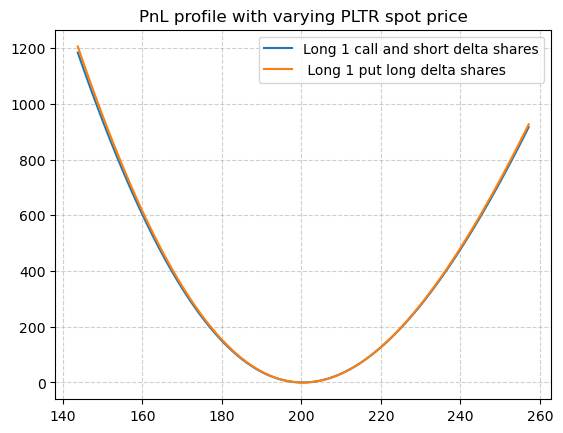

In [22]:
# Given parameters
K = 200
rf = 0.0391
S_0 = 200.47

date_1 = date(2025, 10, 31)
date_2 = date(2026,1,16)
T = (date_2 - date_1).days/365

C_mkt = 23.5
P_mkt = 21

range_of_PLTR_stock_prices = np.linspace(S_0-S_0*sigma_new_call*np.sqrt(T),S_0+S_0*sigma_new_call*np.sqrt(T),num=100)
PnL_port_1 = [contract_multiplier*CallPriceFinder(PLTR_price,K,rf,date_1,date_2,C_mkt,sigma_new_call)-no_of_shares_to_short*PLTR_price-initial_portfolio_val for PLTR_price in range_of_PLTR_stock_prices]
PnL_port_2 = [contract_multiplier*PutPriceFinder(PLTR_price,K,rf,date_1,date_2,P_mkt,sigma_new_put)+no_of_shares_to_buy*PLTR_price-initial_portfolio_val_long_put for PLTR_price in range_of_PLTR_stock_prices]

# plot lines
plt.title("PnL profile with varying PLTR spot price")
plt.plot(range_of_PLTR_stock_prices, PnL_port_1, label = "Long 1 call and short delta shares")
plt.plot(range_of_PLTR_stock_prices, PnL_port_2, label = " Long 1 put long delta shares")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()